# Task 3

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import pandas as pd
from typing import List, Tuple
from scipy.spatial.transform import Rotation
import time
from tqdm.notebook import tqdm

from tools.pcd_tools import downsample_voxel, pcd_from_path
from tools.plot_tools import plot_pcd, show_pcl, view_frames, plot_map_and_trajectories
from tools.analysis_tools import calc_error, calculate_lateral_errors
from tools.dataset import FrameDataset
from tools.ndt_tools import NDT, Pose  # Import the provided NDT implementation


In [3]:
# Paths to dataset
DATASET_DIR = "./dataset"  # Update this to your dataset path
MAP_PATH = os.path.join(DATASET_DIR, "map.pcd")
GT_PATH = os.path.join(DATASET_DIR, "ground_truth.csv")
FRAMES_DIR = os.path.join(DATASET_DIR, "frames")

## Dataset

In [4]:
dataset = FrameDataset(FRAMES_DIR, GT_PATH)
map_pcd = pcd_from_path(MAP_PATH)

print(f"Number of frames: {len(dataset)}")

# Get the first frame
pcd, gt_pos, gt_orientation = dataset[0]

Number of frames: 1014


## NDT Run

In [12]:
# Define parameters
voxel_size = 0.75  # Voxel size for downsampling
max_frames = 1500   # Optional: limit number of frames to process
ndt_cell_size = 3.0
ndt_iterations = 20
num_frames = min(len(dataset), max_frames)

# Lists to track results
gt_positions = []
estimated_positions = []
computation_times = []

# Initialize transformation matrix (identity matrix)
# This will keep track of our current position and orientation
current_transformation = np.eye(4)

# Get the initial pose from ground truth to initialize
init_pcd, init_pos, init_orientation = dataset[0]
yaw = init_orientation[2] # in radians

# Initialize with first ground truth position
current_pose = Pose(init_pos[0], init_pos[1], yaw)
start_time = time.time()  # Start timing
ndt = NDT(ndt_cell_size, ndt_cell_size)
map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size*4)
ndt.set_input_cloud(map_pcd_voxel)
execution_time_ms = (time.time() - start_time) * 1000  # Convert to milliseconds
print(f"Time taken to create NDT and set input cloud: {execution_time_ms:.2f} ms")

i = 0
# Get the current frame
pcd, gt_pos, gt_orientation = dataset[i]

# Store ground truth position
gt_positions.append(gt_pos)

# Voxelize the point clouds to reduce complexity
start_time = time.time()
pcd_voxel, _ = downsample_voxel(pcd, voxel_size)

start_time = time.time()  # Start timing for NDT alignment
pose, _ = ndt.align(pcd_voxel, current_pose, max_iterations=ndt_iterations, eps=0.01)
execution_time_ndt_ms = (time.time() - start_time) * 1000  # Calculate execution time in milliseconds
print(f"Time taken for NDT alignment: {execution_time_ndt_ms:.2f} ms")

# Create transformation matrix from NDT result
R2d, t2d = pose.get_transformation()
ndt_transform = np.eye(4)
ndt_transform[0:2, 0:2] = R2d
ndt_transform[0:2, 3] = t2d.flatten()

# Update the current transformation with the ICP result
# current_transformation = np.matmul(ndt_transform, current_transformation)
current_transformation = ndt_transform

current_pose = pose

# Extract current position from transformation matrix
current_position = current_transformation[:3, 3]

# Store estimated position
estimated_positions.append(current_position)

# Compute error
position_error = np.linalg.norm(current_position - gt_pos)

# Compute execution time
execution_time = time.time() - start_time
computation_times.append(execution_time)

print(f"Execution time: {execution_time:.2f}s")

Time taken to create NDT and set input cloud: 94.41 ms
Time taken for NDT alignment: 5656.86 ms
Execution time: 5.66s


In [ ]:
# Define parameters
voxel_size = 0.5  # Voxel size for downsampling
max_frames = 1500   # Optional: limit number of frames to process
ndt_cell_size = 3.0
ndt_iterations = 20
num_frames = min(len(dataset), max_frames)

# Lists to track results
gt_positions = []
estimated_positions = []
computation_times = []

# Initialize transformation matrix (identity matrix)
# This will keep track of our current position and orientation
current_transformation = np.eye(4)

# Get the initial pose from ground truth to initialize
init_pcd, init_pos, init_orientation = dataset[0]
yaw = init_orientation[2] # in radians

# Initialize with first ground truth position
current_pose = Pose(init_pos[0], init_pos[1], yaw)

# Process frames
pbar = tqdm(range(0, num_frames), desc="Processing frames", leave=True)

# Create ICP object
ndt = NDT(ndt_cell_size, ndt_cell_size)
map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size)
ndt.set_input_cloud(map_pcd_voxel)

for i in pbar:
    # Get the current frame
    pcd, gt_pos, gt_orientation = dataset[i]
    
    # Store ground truth position
    gt_positions.append(gt_pos)
    
    # Voxelize the point clouds to reduce complexity
    start_time = time.time()
    pcd_voxel, _ = downsample_voxel(pcd, voxel_size)


    # Run NDT to align current scan with map
    pose, _ = ndt.align(pcd_voxel, current_pose, max_iterations=ndt_iterations, eps=0.001)
    
    # Create transformation matrix from NDT result
    R2d, t2d = pose.get_transformation()
    ndt_transform = np.eye(4)
    ndt_transform[0:2, 0:2] = R2d
    ndt_transform[0:2, 3] = t2d.flatten()
    
    # Update the current transformation with the ICP result
    # current_transformation = np.matmul(ndt_transform, current_transformation)
    current_transformation = ndt_transform

    current_pose = pose
    
    # Extract current position from transformation matrix
    current_position = current_transformation[:3, 3]
    
    # Store estimated position
    estimated_positions.append(current_position)
    
    # Compute error
    position_error = np.linalg.norm(current_position - gt_pos)
    
    # Compute execution time
    execution_time = time.time() - start_time
    computation_times.append(execution_time)
    
    # Update progress bar with current error
    pbar.set_postfix({"Position Error": f"{position_error:.2f}m", "Time": f"{execution_time:.2f}s"})

# Convert lists to numpy arrays
gt_positions = np.array(gt_positions)
estimated_positions = np.array(estimated_positions)
computation_times = np.array(computation_times)

## Analysis

IndexError: index 161 is out of bounds for axis 0 with size 161

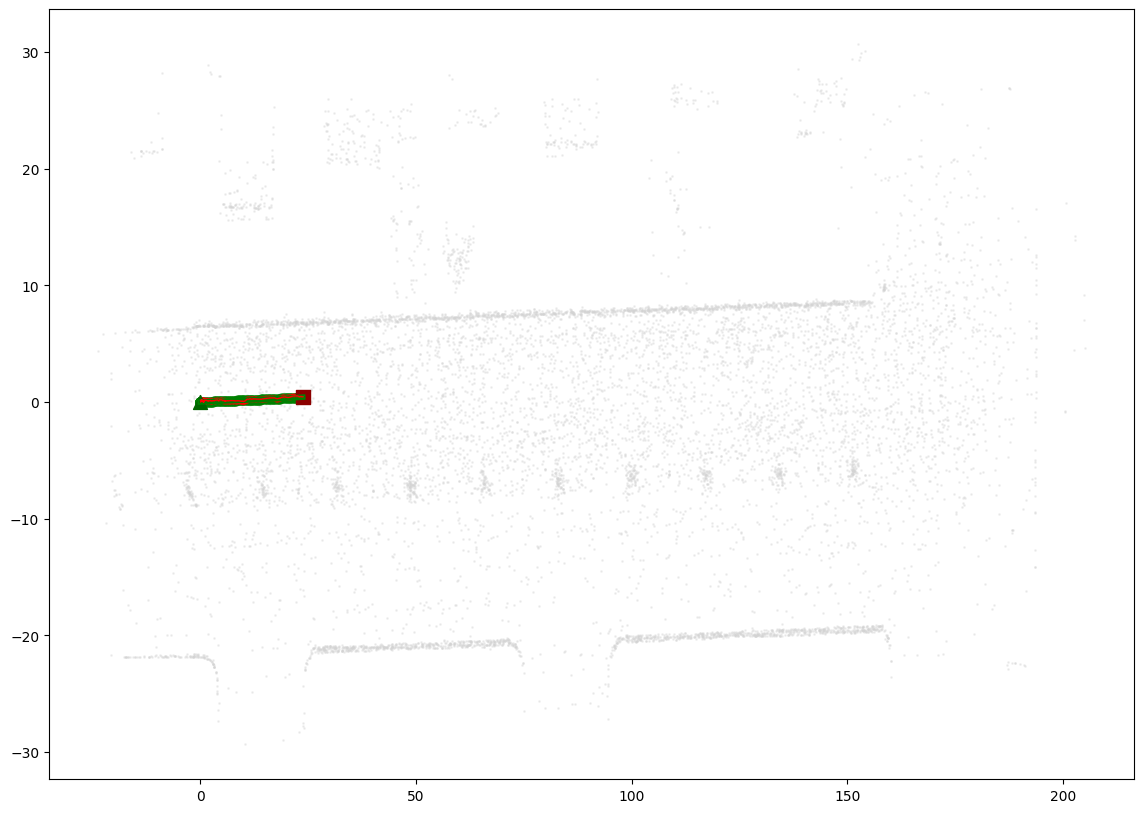

In [49]:
# lateral_errors = calculate_lateral_errors(gt_positions, estimated_positions)
# max_lateral_error = np.max(lateral_errors)
# max_norm_error = np.max(np.linalg.norm(estimated_positions - gt_positions, axis=1))

# # Plot results
# plt.figure(figsize=(12, 8))

# # Plot lateral and norm error over frames in the same plot
# plt.plot(lateral_errors, label='Lateral Error')
# plt.plot(np.linalg.norm(estimated_positions - gt_positions, axis=1), label='Norm Error', color='orange')
# plt.axhline(y=1.2, color='r', linestyle='--', label='Max allowed error (1.2m)')

# # Mark the position of the max lateral error
# max_error_index = np.argmax(lateral_errors)
# plt.scatter(max_error_index, max_lateral_error, color='red', s=100, label=f'Max Lateral Error: {max_lateral_error:.2f} m')
# plt.text(max_error_index, max_lateral_error, f'{max_lateral_error:.2f} m', fontsize=9, ha='right')

# # Mark the position of the max norm error
# max_error_index = np.argmax(np.linalg.norm(estimated_positions - gt_positions, axis=1))
# plt.scatter(max_error_index, max_norm_error, color='blue', s=100, label=f'Max Norm Error: {max_norm_error:.2f} m')
# plt.text(max_error_index, max_norm_error, f'{max_norm_error:.2f} m', fontsize=9, ha='right')

# plt.title("Lateral and Norm Error over Frames")
# plt.xlabel("Frame")
# plt.ylabel("Error (meters)")
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Calculate cumulative errors
# cumulative_lateral_errors = np.cumsum(lateral_errors)
# cumulative_norm_errors = np.cumsum(np.linalg.norm(estimated_positions - gt_positions, axis=1))

# # Plot cumulative lateral errors
# plt.figure(figsize=(12, 8))
# plt.plot(cumulative_lateral_errors, label='Cumulative Lateral Error')
# plt.title("Cumulative Lateral Error over Frames")
# plt.xlabel("Frame")
# plt.ylabel("Cumulative Error (meters)")
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Plot cumulative norm errors
# plt.figure(figsize=(12, 8))
# plt.plot(cumulative_norm_errors, label='Cumulative Norm Error', color='orange')
# plt.title("Cumulative Norm Error over Frames")
# plt.xlabel("Frame")
# plt.ylabel("Cumulative Error (meters)")
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Plot computation times across frames
# plt.figure(figsize=(12, 8))
# plt.plot(computation_times, label='Computation Time', color='purple')
# plt.title("Computation Times over Frames")
# plt.xlabel("Frame")
# plt.ylabel("Time (seconds)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

plot_map_and_trajectories(map_pcd, gt_positions, estimated_positions)